# MLP Runtime Analysis

This notebook visualizes the runtime of MLP implementations for different hidden layer sizes, using the results from the `results_mlp` directory.

In [2]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# Directory containing result files
result_dir = Path("results_mlp")
results = {}

# Parse all .log files in the directory, including avx_double.log
for log_file in result_dir.glob("*.log"):
    name = log_file.stem  # filename without extension
    with open(log_file, "r") as f:
        content = f.read()
        # Find all hidden layer sizes and their corresponding runtimes
        sizes = [int(s) for s in re.findall(r"Hidden layer size: (\d+)", content)]
        # Only match lines that are just a float (not part of an error message)
        times = [float(t) for t in re.findall(r"^([0-9]*\.[0-9]+)$", content, re.MULTILINE)]
        # Map each size to its runtime (skip if counts don't match)
        # If there are duplicate sizes, keep a list of all times for that size
        for s, t in zip(sizes[-len(times):], times):
            # Use the last N sizes, where N is the number of times found
            results.setdefault(name, {})[s] = t

results

{'avx_double': {128: 4.2e-05,
  256: 8.4e-05,
  512: 0.000166,
  1024: 0.000332,
  2048: 0.000668},
 'avx_float': {128: 2.6e-05,
  256: 3.8e-05,
  512: 7.5e-05,
  1024: 0.00015,
  2048: 0.000306},
 'og_double': {128: 0.000113,
  256: 0.000222,
  512: 0.000448,
  1024: 0.000899,
  2048: 0.004121},
 'og_float': {128: 9.6e-05,
  256: 0.00019,
  512: 0.000378,
  1024: 0.000755,
  2048: 0.001853}}

In [4]:
# Convert results to DataFrame for visualization
# Each row: hidden layer size, each column: implementation (file)
df = pd.DataFrame(results)
df = df.sort_index()
df

,avx_double,avx_float,og_double,og_float
128,0.000042,0.000026,0.000113,0.000096
256,0.000084,0.000038,0.000222,0.000190
512,0.000166,0.000075,0.000448,0.000378
1024,0.000332,0.000150,0.000899,0.000755
2048,0.000668,0.000306,0.004121,0.001853


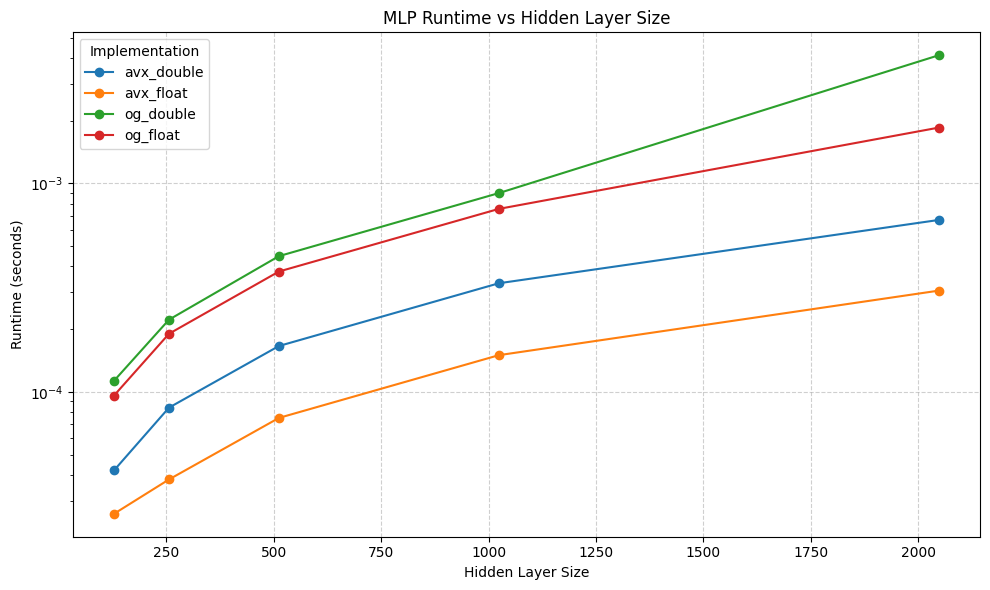

In [5]:
# Plot runtimes for each implementation as a function of hidden layer size
plt.figure(figsize=(10, 6))
for col in df.columns:
    plt.plot(df.index, df[col], marker='o', label=col)
plt.xlabel('Hidden Layer Size')
plt.ylabel('Runtime (seconds)')
plt.title('MLP Runtime vs Hidden Layer Size')
plt.yscale('log')
plt.legend(title='Implementation')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [8]:
# Generate a LaTeX table from the DataFrame, numbers f
latex_table = df.to_latex(float_format="%.6f", caption="Runtime of MLP implementations with different hidden layer sizes", label="tab:mlp_runtimes", index_names=False, escape=False)
print(latex_table)

\begin{table}
\caption{Runtime of MLP implementations with different hidden layer sizes}
\label{tab:mlp_runtimes}
\begin{tabular}{lrrrr}
\toprule
 & avx_double & avx_float & og_double & og_float \\
\midrule
128 & 0.000042 & 0.000026 & 0.000113 & 0.000096 \\
256 & 0.000084 & 0.000038 & 0.000222 & 0.000190 \\
512 & 0.000166 & 0.000075 & 0.000448 & 0.000378 \\
1024 & 0.000332 & 0.000150 & 0.000899 & 0.000755 \\
2048 & 0.000668 & 0.000306 & 0.004121 & 0.001853 \\
\bottomrule
\end{tabular}
\end{table}

